              precision    recall  f1-score   support

 non-healing       1.00      0.33      0.50         3
     healing       0.87      1.00      0.93        13

   micro avg       0.88      0.88      0.88        16
   macro avg       0.93      0.67      0.71        16
weighted avg       0.89      0.88      0.85        16
 samples avg       0.88      0.88      0.88        16

Accuracy: 87.5 %


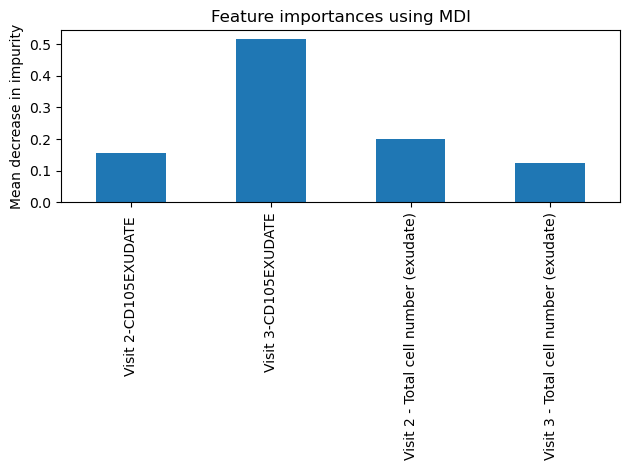

[[0.29523498 0.70240134]
 [0.11936411 0.8811264 ]
 [0.3293649  0.6258367 ]
 [0.1727919  0.84803426]
 [0.10278857 0.90356606]
 [0.23186812 0.78856415]
 [0.37186626 0.68010867]
 [0.07655345 0.92288494]
 [0.18284243 0.8351993 ]
 [0.53151613 0.44578636]
 [0.26021805 0.7825937 ]
 [0.3915201  0.53694975]
 [0.13325806 0.85986686]
 [0.3450398  0.65856135]
 [0.07339162 0.92963934]
 [0.12058195 0.9025528 ]]
[[False  True]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [ True False]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [False  True]
 [False  True]]


<Figure size 40000x12000 with 0 Axes>

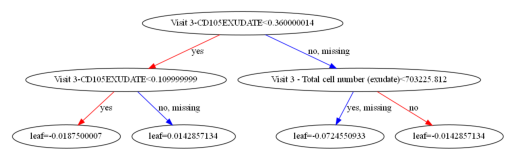

--------------------------------------------------------------------------------------------------


In [25]:
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import tree
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pandas as pd
import re
import random
from tensorflow.keras.utils import to_categorical
from sklearn.tree import DecisionTreeClassifier
from sklearn.impute import SimpleImputer
import xgboost as xgb
from xgboost import plot_tree
from xgboost import XGBClassifier
from dtreeviz import model


Treatment=pd.read_csv("../dissertation/CD105 cell.csv")
Treatment_test=pd.read_csv("../dissertation/CD105 cell test.csv")
X_train=Treatment.iloc[:,1:]
df_y=Treatment.iloc[:,0]

X_test=Treatment_test.iloc[:,1:]
df_y_test=Treatment_test.iloc[:,0]


y_train = to_categorical(df_y)
y_test = to_categorical(df_y_test)


names=["CD V2","CD V3","V1","V2","V3"]
W_tree=2


clf=XGBClassifier(booster="dart",
                  normalize_type="forest",
                  tree_method="exact",
                  #objective="reg:pseudohubererror",
                  eta=0.05,
                  max_depth=None,
                  #subsample=0.5,
                #  colsample_bytree=0.7,
                  #colsample_bylevel=0.3,
                  colsample_bynode=0.6,
                  reg_lambda=0.6,
                  reg_alpha=0.4,
                  rate_drop=1,
                  skip_drop=0.5,
                  one_drop=1,
                  sample_type="weighted",
                  
    )




clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)
y_pred = (y_pred > 0.5) 

print(classification_report(y_test,y_pred,output_dict=False,target_names=["non-healing","healing"]))


accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", (accuracy*100),"%")

names=clf.get_booster().feature_names

importances = clf.feature_importances_
forest_importances = pd.Series(importances, index=names)

fig, ax = plt.subplots()
forest_importances.plot.bar( ax=ax)
ax.set_title("Feature importances using MDI")
ax.set_ylabel("Mean decrease in impurity")
fig.tight_layout()
plt.show()

f = open("out.txt", "w")
var=clf.get_booster().get_dump()
for line in var:
    f.write(f"{line}\n")
f.close()

print(clf.predict_proba(X_test))
print(y_pred)


plt.figure(figsize=(400, 120))
plot_tree(clf, num_trees=W_tree)
plt.show()








print("--------------------------------------------------------------------------------------------------")

target = 'key'
class_names=["non-healing","healing"]


#Which_data=df_y_test
Which_data=df_y

from supertree import SuperTree
st = SuperTree(
    clf, 
    X_test, 
    Which_data, 
    names, 
    class_names
)
# Visualize the tree
st.show_tree(which_tree=W_tree)